Output directory: /Users/munkhsuld/SkyResortPlots


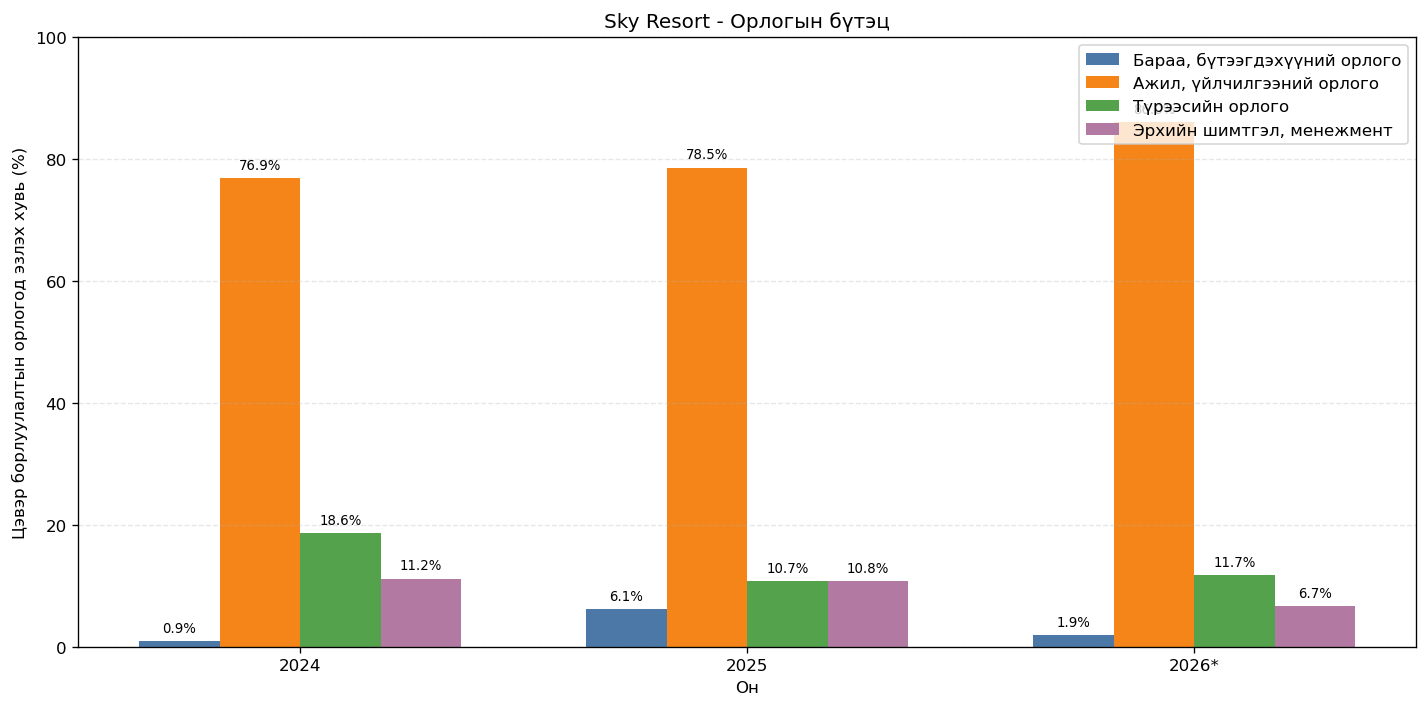

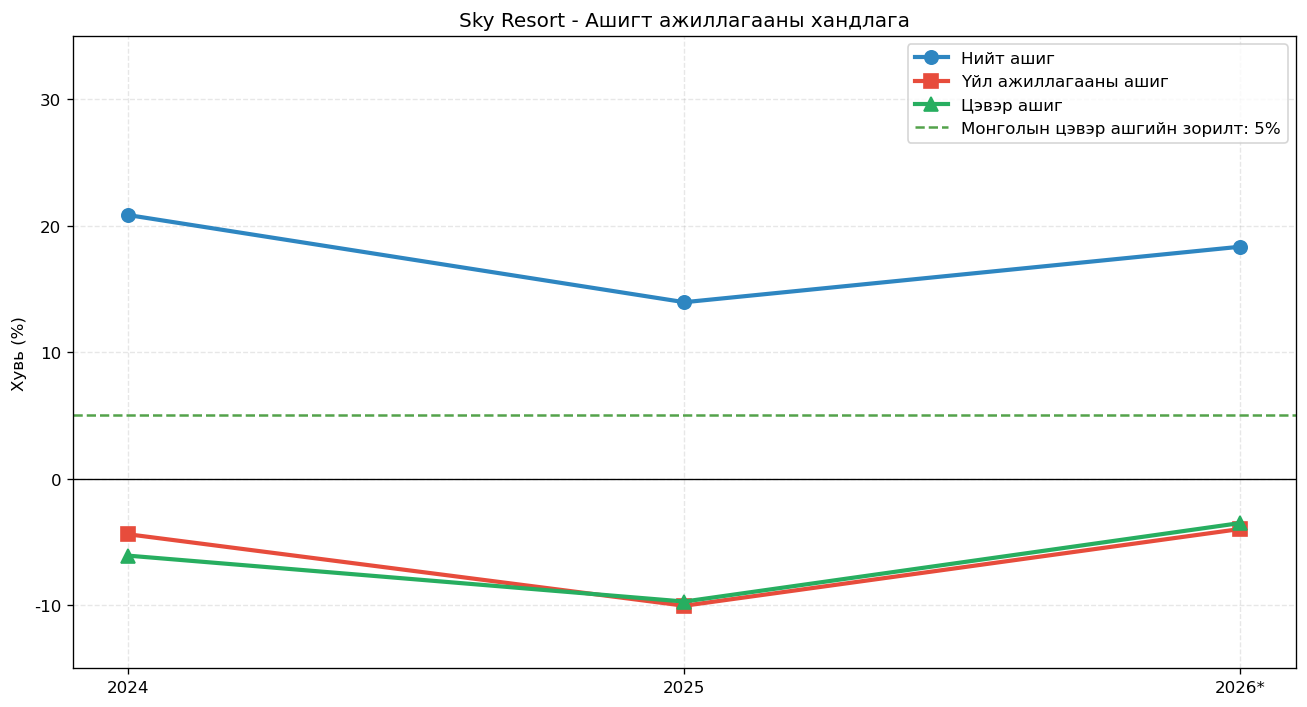

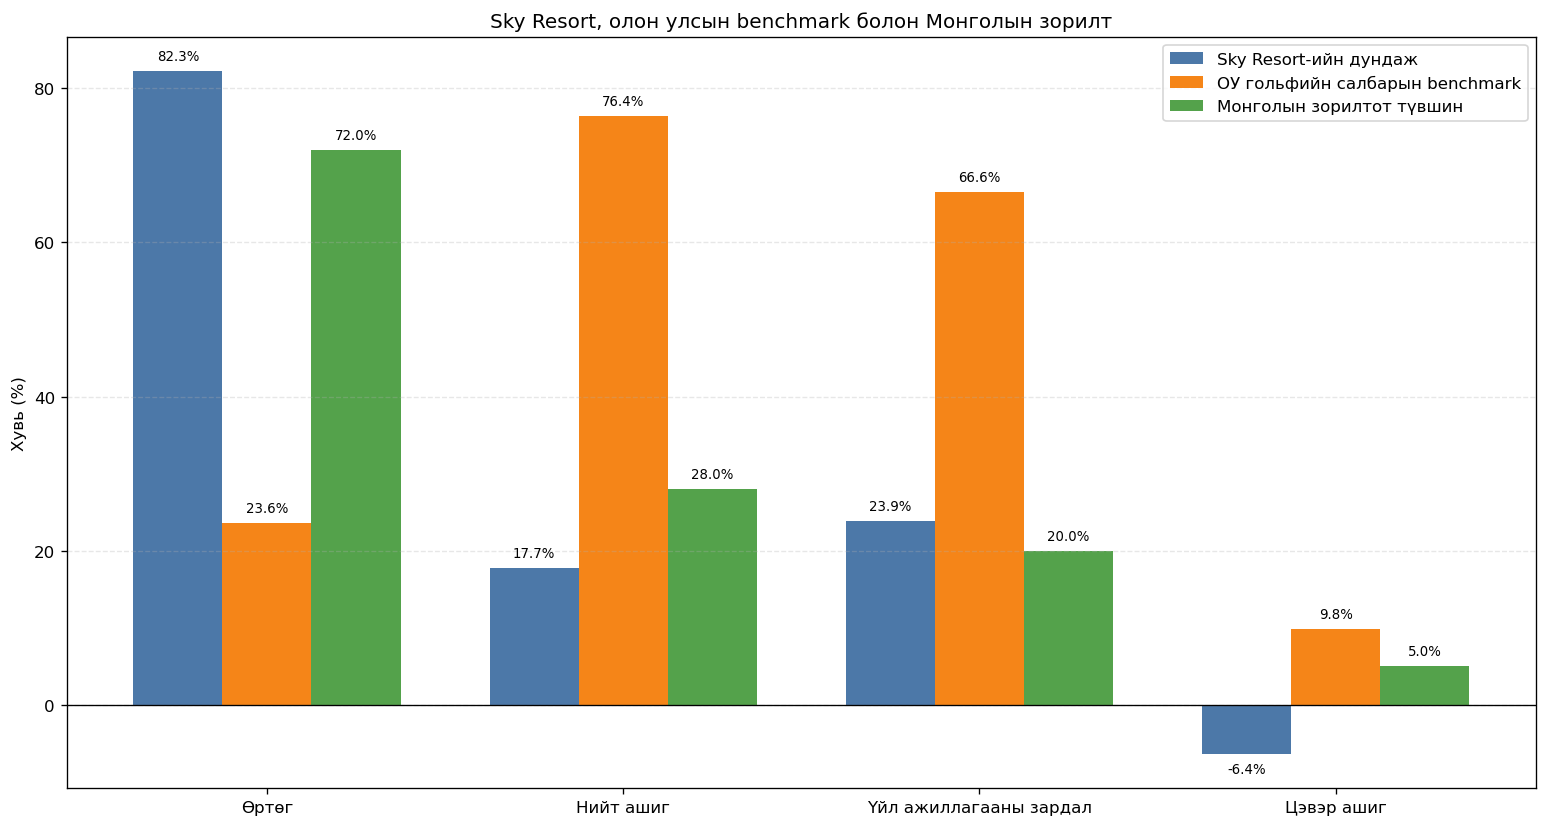

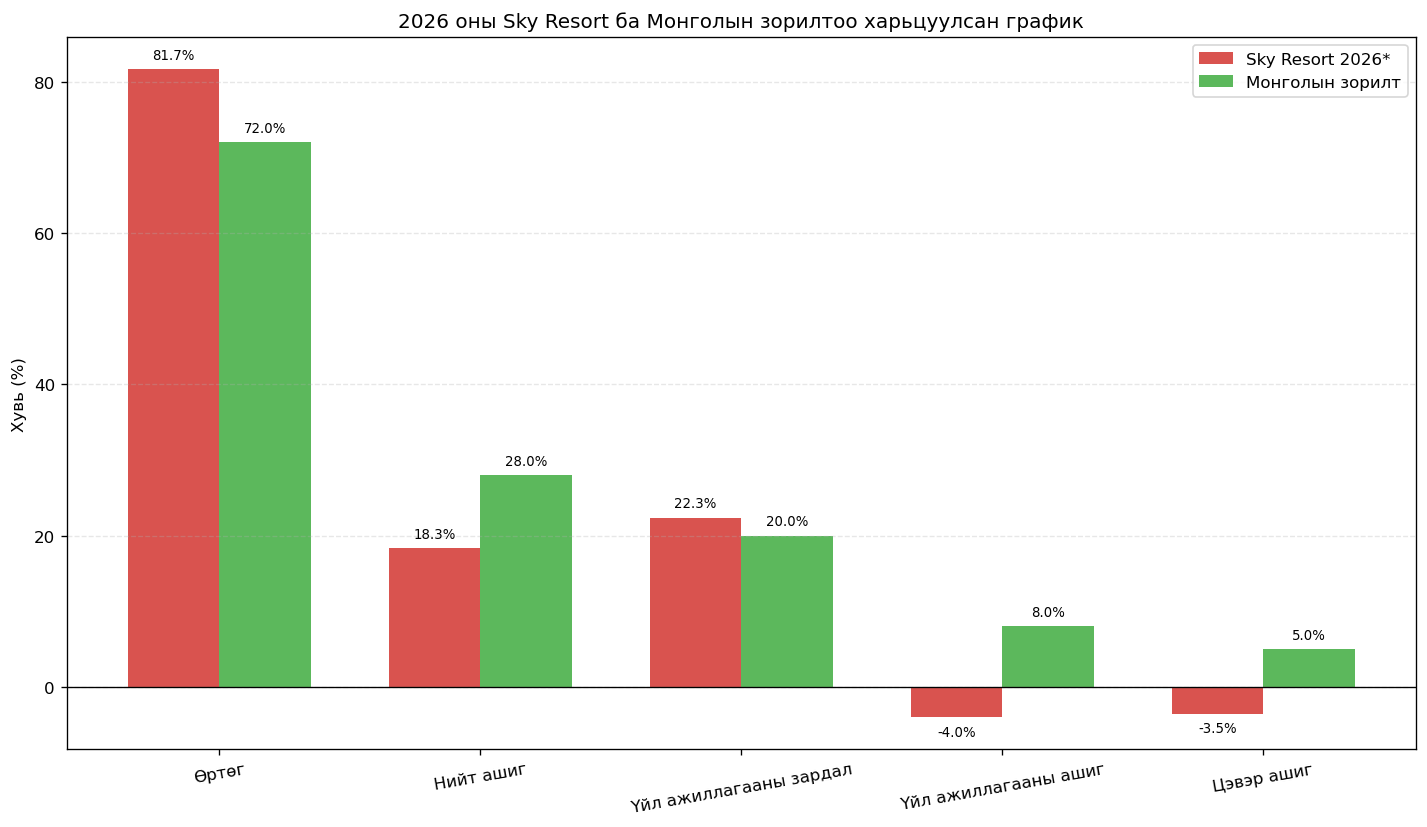

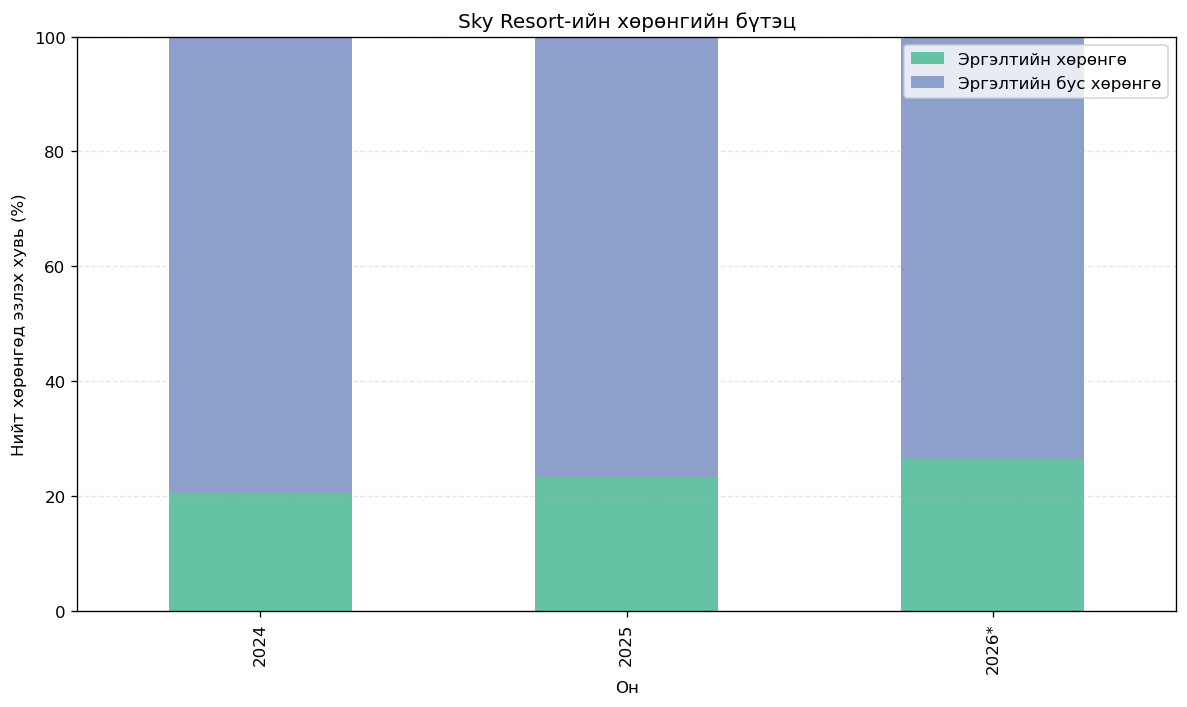

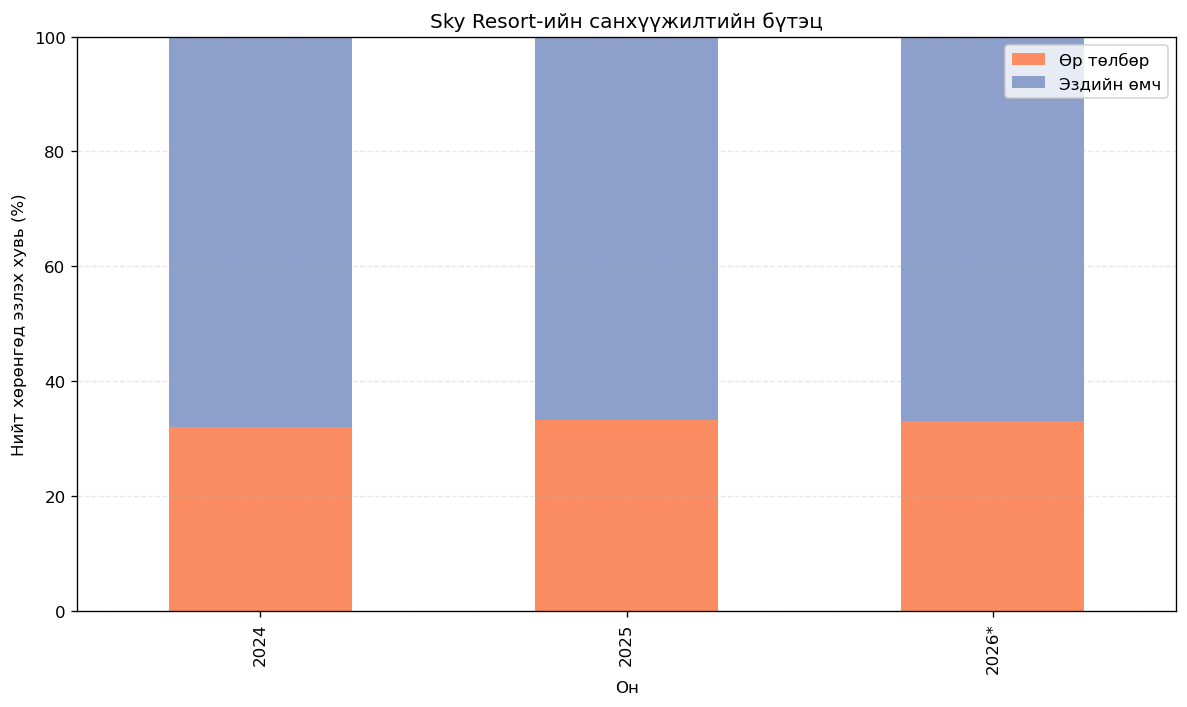


Амжилттай ажиллалаа.
Графикууд хадгалагдлаа: /Users/munkhsuld/SkyResortPlots
Excel файл: /Users/munkhsuld/SkyResortPlots/sky_resort_vertical_analysis.xlsx


In [2]:
import os
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =====================================================
# 0. Бичих боломжтой хавтас сонгох
# =====================================================
def get_writable_output_dir():
    candidates = [
        Path.cwd() / "SkyResortPlots",
        Path.home() / "SkyResortPlots",
        Path.home() / "Desktop" / "SkyResortPlots",
        Path("/mnt/data") / "SkyResortPlots",
        Path(tempfile.gettempdir()) / "SkyResortPlots",
    ]

    for folder in candidates:
        try:
            folder.mkdir(parents=True, exist_ok=True)

            test_file = folder / "write_test.txt"
            test_file.write_text("ok", encoding="utf-8")
            test_file.unlink()
            return folder

        except Exception:
            continue

    raise OSError("Бичих боломжтой хавтас олдсонгүй. Дээрх directory-ууд руу автомат бичих боломжгүй.")

output_dir = get_writable_output_dir()
print(f"Output directory: {output_dir}")

# =====================================================
# 1. Ерөнхий тохиргоо
# =====================================================
plt.rcParams["font.family"] = "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

years = ["2024", "2025", "2026*"]

# =====================================================
# 2. Sky Resort-ийн бодит өгөгдөл
# =====================================================
sky_income = pd.DataFrame({
    "Бараа, бүтээгдэхүүний орлого": [0.86, 6.13, 1.92],
    "Ажил, үйлчилгээний орлого": [76.87, 78.55, 86.05],
    "Түрээсийн орлого": [18.56, 10.74, 11.67],
    "Эрхийн шимтгэл, менежмент": [11.16, 10.78, 6.65],

    "Өртөг": [79.16, 86.05, 81.66],
    "Нийт ашиг": [20.84, 13.95, 18.34],
    "Ерөнхий ба удирдлагын зардал": [19.65, 18.20, 18.36],
    "Борлуулалт, маркетингийн зардал": [5.58, 5.81, 3.97],
    "Үйл ажиллагааны зардал": [25.23, 24.01, 22.33],
    "Үйл ажиллагааны ашиг": [-4.40, -10.05, -3.98],
    "Цэвэр ашиг": [-6.09, -9.72, -3.51]
}, index=years)

# =====================================================
# 3. Олон улсын гольфийн салбарын benchmark
# =====================================================
# 2024 оны Канадын golf courses and country clubs салбарын benchmark
industry = {
    "Өртөг": 23.6,
    "Нийт ашиг": 76.4,
    "Үйл ажиллагааны зардал": 66.6,
    "Цэвэр ашиг": 9.8
}

# =====================================================
# 4. Монголын зорилтот түвшин
# =====================================================
mongolia_target = {
    "Өртөг": 72.0,
    "Нийт ашиг": 28.0,
    "Үйл ажиллагааны зардал": 20.0,
    "Үйл ажиллагааны ашиг": 8.0,
    "Цэвэр ашиг": 5.0
}

# =====================================================
# 5. Балансын өгөгдөл
# =====================================================
balance = pd.DataFrame({
    "Эргэлтийн хөрөнгө": [20.44, 23.30, 26.43],
    "Эргэлтийн бус хөрөнгө": [79.56, 76.70, 73.57],
    "Өр төлбөр": [31.93, 33.16, 33.12],
    "Эздийн өмч": [68.07, 66.84, 66.88]
}, index=years)

# =====================================================
# 6. Helper function for labels
# =====================================================
def add_bar_labels(ax, bars, decimals=1):
    for bar in bars:
        height = bar.get_height()

        if np.isnan(height):
            continue

        if height >= 0:
            y_position = height + 1
            va = "bottom"
        else:
            y_position = height - 1
            va = "top"

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            y_position,
            f"{height:.{decimals}f}%",
            ha="center",
            va=va,
            fontsize=8
        )

# =====================================================
# 7. Graph 1: Орлогын бүтэц
# =====================================================
revenue = sky_income[[
    "Бараа, бүтээгдэхүүний орлого",
    "Ажил, үйлчилгээний орлого",
    "Түрээсийн орлого",
    "Эрхийн шимтгэл, менежмент"
]]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(years))
width = 0.18
colors = ["#4C78A8", "#F58518", "#54A24B", "#B279A2"]

for i, column in enumerate(revenue.columns):
    bars = ax.bar(
        x + (i - 1.5) * width,
        revenue[column],
        width=width,
        label=column,
        color=colors[i]
    )
    add_bar_labels(ax, bars)

ax.set_title("Sky Resort - Орлогын бүтэц")
ax.set_xlabel("Он")
ax.set_ylabel("Цэвэр борлуулалтын орлогод эзлэх хувь (%)")
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(output_dir / "01_revenue_structure.png", dpi=300)
plt.show()

# =====================================================
# 8. Graph 2: Ашигт ажиллагааны хандлага
# =====================================================
fig, ax = plt.subplots(figsize=(11, 6))

profitability = ["Нийт ашиг", "Үйл ажиллагааны ашиг", "Цэвэр ашиг"]
colors = {"Нийт ашиг": "#2E86C1", "Үйл ажиллагааны ашиг": "#E74C3C", "Цэвэр ашиг": "#27AE60"}
markers = {"Нийт ашиг": "o", "Үйл ажиллагааны ашиг": "s", "Цэвэр ашиг": "^"}

for metric in profitability:
    ax.plot(
        years,
        sky_income[metric],
        marker=markers[metric],
        markersize=8,
        linewidth=2.5,
        label=metric,
        color=colors[metric]
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.axhline(mongolia_target["Цэвэр ашиг"], color="#54A24B", linestyle="--", linewidth=1.5, label="Монголын цэвэр ашгийн зорилт: 5%")
ax.set_title("Sky Resort - Ашигт ажиллагааны хандлага")
ax.set_ylabel("Хувь (%)")
ax.set_ylim(-15, 35)
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "02_profitability_trend.png", dpi=300)
plt.show()

# =====================================================
# 9. Graph 3: Sky Resort vs Industry benchmark vs Mongolia target
# =====================================================
metrics = ["Өртөг", "Нийт ашиг", "Үйл ажиллагааны зардал", "Цэвэр ашиг"]
sky_average = sky_income[metrics].mean()

comparison = pd.DataFrame({
    "Sky Resort 2024–2026 дундаж": sky_average.values,
    "ОУ гольфийн салбарын benchmark": [
        industry["Өртөг"],
        industry["Нийт ашиг"],
        industry["Үйл ажиллагааны зардал"],
        industry["Цэвэр ашиг"]
    ],
    "Монголын зорилтот түвшин": [
        mongolia_target["Өртөг"],
        mongolia_target["Нийт ашиг"],
        mongolia_target["Үйл ажиллагааны зардал"],
        mongolia_target["Цэвэр ашиг"]
    ]
}, index=metrics)

fig, ax = plt.subplots(figsize=(13, 7))
x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, comparison["Sky Resort 2024–2026 дундаж"], width, label="Sky Resort-ийн дундаж", color="#4C78A8")
bars2 = ax.bar(x, comparison["ОУ гольфийн салбарын benchmark"], width, label="ОУ гольфийн салбарын benchmark", color="#F58518")
bars3 = ax.bar(x + width, comparison["Монголын зорилтот түвшин"], width, label="Монголын зорилтот түвшин", color="#54A24B")

add_bar_labels(ax, bars1)
add_bar_labels(ax, bars2)
add_bar_labels(ax, bars3)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Sky Resort, олон улсын benchmark болон Монголын зорилт")
ax.set_ylabel("Хувь (%)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "03_industry_benchmark_comparison.png", dpi=300)
plt.show()

# =====================================================
# 10. Graph 4: 2026 бодит vs Монголын зорилт
# =====================================================
metrics_2026 = ["Өртөг", "Нийт ашиг", "Үйл ажиллагааны зардал", "Үйл ажиллагааны ашиг", "Цэвэр ашиг"]

sky_2026 = {
    metric: sky_income.loc["2026*", metric]
    for metric in metrics_2026
}

target_2026 = {
    metric: mongolia_target.get(metric, np.nan)
    for metric in metrics_2026
}

comparison_2026 = pd.DataFrame({
    "Sky Resort 2026*": sky_2026,
    "Монголын зорилт": target_2026
}, index=metrics_2026)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(metrics_2026))
width = 0.35

bars1 = ax.bar(x - width / 2, comparison_2026["Sky Resort 2026*"], width, label="Sky Resort 2026*", color="#D9534F")
bars2 = ax.bar(x + width / 2, comparison_2026["Монголын зорилт"], width, label="Монголын зорилт", color="#5CB85C")

add_bar_labels(ax, bars1)
add_bar_labels(ax, bars2)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("2026 оны Sky Resort ба Монголын зорилтоо харьцуулсан график")
ax.set_ylabel("Хувь (%)")
ax.set_xticks(x)
ax.set_xticklabels(metrics_2026, rotation=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "04_2026_vs_target.png", dpi=300)
plt.show()

# =====================================================
# 11. Graph 5: Балансын хөрөнгийн бүтэц
# =====================================================
fig, ax = plt.subplots(figsize=(10, 6))
balance[["Эргэлтийн хөрөнгө", "Эргэлтийн бус хөрөнгө"]].plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#66C2A5", "#8DA0CB"]
)
ax.set_title("Sky Resort-ийн хөрөнгийн бүтэц")
ax.set_xlabel("Он")
ax.set_ylabel("Нийт хөрөнгөд эзлэх хувь (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(output_dir / "05_asset_structure.png", dpi=300)
plt.show()

# =====================================================
# 12. Graph 6: Өр төлбөр ба өмчийн бүтэц
# =====================================================
fig, ax = plt.subplots(figsize=(10, 6))
balance[["Өр төлбөр", "Эздийн өмч"]].plot(
    kind="bar",
    stacked=True,
    ax=ax,
    color=["#FC8D62", "#8DA0CB"]
)
ax.set_title("Sky Resort-ийн санхүүжилтийн бүтэц")
ax.set_xlabel("Он")
ax.set_ylabel("Нийт хөрөнгөд эзлэх хувь (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig(output_dir / "06_liabilities_equity.png", dpi=300)
plt.show()

# =====================================================
# 13. Excel файл хадгалах
# =====================================================
excel_path = output_dir / "sky_resort_vertical_analysis.xlsx"

with pd.ExcelWriter(excel_path) as writer:
    sky_income.to_excel(writer, sheet_name="Sky Resort actual")
    comparison.to_excel(writer, sheet_name="Industry comparison")
    comparison_2026.to_excel(writer, sheet_name="2026 target comparison")
    balance.to_excel(writer, sheet_name="Balance structure")

print("\nАмжилттай ажиллалаа.")
print(f"Графикууд хадгалагдлаа: {output_dir}")
print(f"Excel файл: {excel_path}")